# 05. 반복 실험과 ε 값에 따른 학습 결과 비교

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from bandit import Bandit, Agent
plt.rcParams['font.family'] = 'AppleGothic'   # macOS

plt.rcParams['axes.unicode_minus'] = False

rng = np.random.default_rng(22)

## 200번의 반복 실험


In [2]:
# 실험 수
runs = 200

# 시도 횟수 지정 
N = 1000

# 무작위로 슬롯머신를 선택할 확률을 지정 
epsilon = 0.1

# 슬롯머신 수 지정 
K = 10


# 기록용 목록 초기화
all_rates = np.zeros((runs, N))
for run in range(runs):

    bandit = Bandit(K)
    agent = Agent(epsilon, K)

    total_reward = 0
    rates = []

    # 반복 시도 
    for n in range(N):
        # ε-greedy법으로 플레이할 슬롯머신 번호를 결정
        action = agent.get_action()
        
        # action번째 슬롯머신 플레이
        reward = bandit.play(action)
        
        # action 번째 슬롯머신의 추정 가치 업데이트
        agent.update(action, reward)
        
        # 보상 추가
        total_reward +=reward
        rates.append(total_reward / (n + 1))
    
    all_rates[run] = rates


avg_rates = np.average(all_rates, axis=0)
print(avg_rates[N-1])

0.9073249999999997


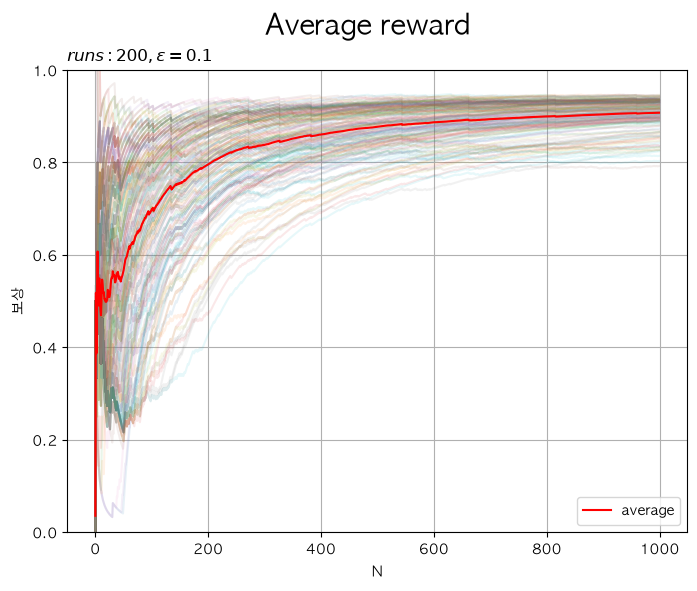

In [3]:
plt.figure(figsize=(8, 6))
for run in range(runs):
    plt.plot(all_rates[run], alpha=0.1)  # 한 번의 실험에서 얻은 평균 보상 곡선
plt.plot(avg_rates, color='red', label='average')
plt.xlabel('N')
plt.ylabel('보상')
plt.title('$runs:'+str(runs) + ', \epsilon='+str(epsilon)+'$', loc='left') # 実験の設定
plt.suptitle('Average reward', fontsize=20) # 결과를 200개 실험에 걸쳐 평균한 곡선
plt.grid()
plt.legend()
plt.ylim(0, 1)
plt.show()

## ε 값을 바꾸어 실험하기

ε은 매 행동 선택에서 무작위 탐험을 수행할 확률이다. 값이 작으면 현재 추정치가 높은 머신을 더 자주 활용하고, 값이 크면 여러 머신을 더 자주 탐험한다.


In [4]:
# 실험 수
runs = 200

# 시도 횟수 지정 
N = 1000

# 무작위로 슬롯머신를 선택할 확률을 지정 
epsilon_list = [0.01, 0.05, 0.1, 0.3, 0.5]

# 슬롯머신 수 지정 
K = 10


# 기록용 목록 초기화
all_rates = np.zeros((runs, N))
all_avg_rates = np.zeros((len(epsilon_list), N))
for m, epsilon in enumerate(epsilon_list):
    print('epsilon =', epsilon)
    for run in range(runs):

        bandit = Bandit(K)
        agent = Agent(epsilon, K)

        total_reward = 0
        rates = []

        # 반복 시도 
        for n in range(N):
            # ε-greedy법으로 플레이할 슬롯머신 번호를 결정
            action = agent.get_action()
            
            # action번째 슬롯머신 플레이
            reward = bandit.play(action)
            
            # action 번째 슬롯머신의 예상 가치 업데이트
            agent.update(action, reward)
            
            # 보상 추가
            total_reward +=reward
            rates.append(total_reward / (n + 1))
        
        all_rates[run] = rates


    avg_rates = np.average(all_rates, axis=0)
    print(avg_rates[N-1])
    all_avg_rates[m] = avg_rates

epsilon = 0.01
0.7462999999999995
epsilon = 0.05
0.907655
epsilon = 0.1
0.9082500000000003
epsilon = 0.3
0.83898
epsilon = 0.5
0.7474950000000001


## 6. ε에 따른 학습 곡선 비교



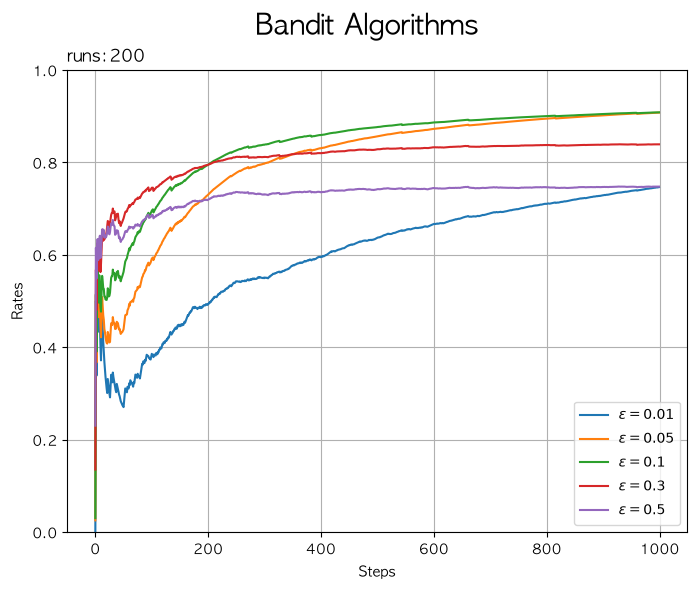

In [5]:
plt.figure(figsize=(8, 6))
for i, epsilon in enumerate(epsilon_list):
    plt.plot(all_avg_rates[i], label='$\epsilon='+str(epsilon)+'$') 
plt.xlabel('Steps')
plt.ylabel('Rates')
plt.title('runs:' + str(runs), loc='left') 
plt.suptitle('Bandit Algorithms', fontsize=20)
plt.grid()
plt.legend()
plt.ylim(0, 1)
plt.show()